# Machine Learning Project: Iris Classification with Decision Tree


## Introduction
This project is a beginner-friendly machine learning classification task based on the Iris dataset.

The objective is to build a model that can predict the species of a flower from its measurements.


## Why this project?
This project is suitable for a new user in machine learning because it introduces:
- Structured data
- Features and target variables
- Data exploration
- Model training
- Prediction
- Evaluation

## Dataset
The Iris dataset contains flower measurements and corresponding species labels.


### Input Features
- Sepal length
- Sepal width
- Petal length
- Petal width

### Output Classes
- Setosa
- Versicolor
- Virginica

## Model Used
In this notebook, we will use a **Decision Tree Classifier**.

A decision tree learns simple rules from the data and uses those rules to make predictions.

# CODE

## Core libraries for Data Handling

In [3]:
import pandas as pd
import numpy as np


## Libraries for visualization

In [107]:
import matplotlib.pyplot as plt

## Scikit-learn tools

In [108]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

# Step 1 : Load the dataset

### Load the iris dataset

In [109]:
iris_data = load_iris()

### Store the input data and labels separately

In [110]:
features = iris_data.data
labels = iris_data.target

In [111]:
features.shape

(150, 4)

In [112]:
labels.shape

(150,)

### Print basic information

In [113]:
print("Feature array shape:", features.shape)
print("Label array shape:", labels.shape)
print("Target names:", iris_data.target_names)

Feature array shape: (150, 4)
Label array shape: (150,)
Target names: ['setosa' 'versicolor' 'virginica']


# Step 2: Convert the dataset into a DataFrame


Although Scikit-learn provides the data as arrays,
working with a Pandas DataFrame is easier for analysis and readability.

A DataFrame allows us to:
- inspect rows and columns clearly
- summarize numerical values
- check distributions
- prepare data for modeling

In [114]:
iris_df = pd.DataFrame(features, columns=iris_data.feature_names)

In [115]:
iris_df['target'] = labels

In [116]:
species_names = {0 : "setosa", 1:"versicolor", 2:"virginica"}
iris_df['species'] = iris_df['target'].map(species_names)

In [117]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Step 3: Understand the dataset

Before training a model, we should inspect the data carefully.

This includes:
- checking the number of rows and columns
- reviewing data types
- looking for missing values
- understanding class balance
- examining summary statistics

This step matters because blind modeling is lazy work.
First understand the data, then build the model.

In [118]:
print("\nDataset shape:")

print(iris_df.shape)


Dataset shape:
(150, 6)


In [119]:
print("\nData types:")
print(iris_df.dtypes)



Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species               object
dtype: object


In [120]:
print("\nMissing values:")
print(iris_df.isna().sum())


Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [121]:
print("\nClass Distribution:")
print(iris_df["species"].value_counts())


Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [122]:
print("\nClass distribution:")
print(iris_df["species"].value_counts())


Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [123]:
print("\nSummary statistics:")
print(iris_df.describe())


Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


## Step 4: Visual inspection of feature averages by species

A model will learn patterns from numerical values.
So it is helpful to compare average measurements across species.

This gives us a first feel for whether the classes look separable.

In [124]:
group_means= iris_df.groupby("species")[iris_data.feature_names].mean()
group_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


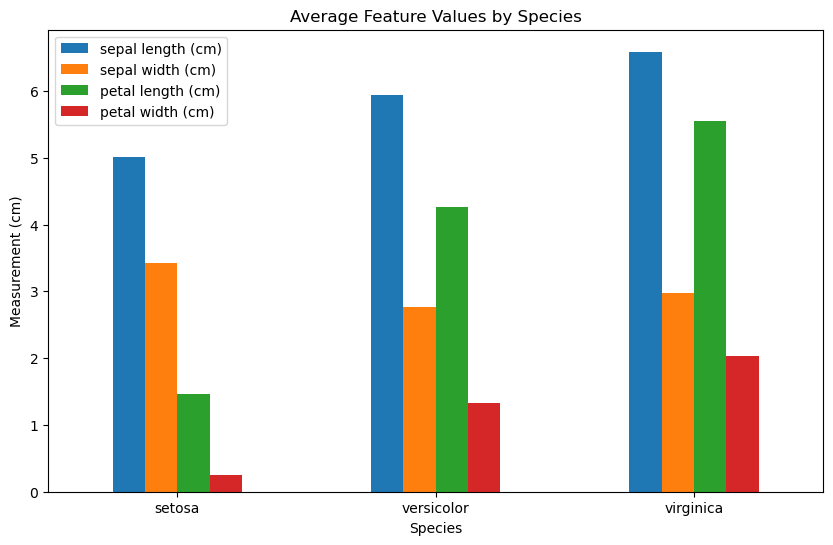

In [125]:
group_means.plot(kind="bar",figsize=(10,6))
plt.title("Average Feature Values by Species")
plt.xlabel("Species")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=0)
plt.show()
          

## Step 5: Define X and y

In machine learning:
- **X** represents the input features
- **y** represents the target we want to predict

In this dataset:
- X = flower measurements
- y = species label

In [126]:
X = iris_df[iris_data.feature_names]
y = iris_df["target"]

print("X shape:" , X.shape)
print("y shape:" , y.shape)

X shape: (150, 4)
y shape: (150,)


## Step 6: Split the dataset into training and test data


We do not train and test on the same data.
That would give a fake sense of success.

Instead:
- the training data is used to teach the model
- the test data is used to check how well the model performs on unseen observations

This is one of the most basic and important habits in machine learning.

In [127]:
X_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

print("Training feature shape:" , X_train.shape)
print("Testing feature shape:" , x_test.shape)
print("Traning target shape:" , y_train.shape)
print("Testing target shape:" , y_test.shape)

Training feature shape: (112, 4)
Testing feature shape: (38, 4)
Traning target shape: (112,)
Testing target shape: (38,)


## Step 7: Build the model


We will use a **Decision Tree Classifier**.

A decision tree works by asking a sequence of questions about the input features.
For example:
- is petal length less than a certain value?
- is petal width greater than a threshold?

By repeating this process, the tree separates the data into classes.

In [128]:
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=7
)

tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Step 8: Generate predictions

Now that the model has learned from the training data,
we can use it to predict the flower species in the test set.

In [129]:
predications = tree_model.predict(X_test)

print("Predicted labels:")
print(predications[:10])

Predicted labels:
[0 0 2 1 0 1 0 2 0 2]


## Step 9: Compare actual and predicted values

One of the easiest ways to inspect model output
is to place actual and predicted labels side by side.

In [130]:

comparison_df = X_test.copy()
comparison_df["actual_label"] = y_test.values
comparison_df["predicated_label"] = predications

comparison_df["actaul_species"] = comparison_df["actual_label"].map(species_names)
comparison_df["predicated_species"] = comparison_df["predicated_label"].map(species_names)

comparison_df.head(15)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_label,predicated_label,actaul_species,predicated_species
38,4.4,3.0,1.3,0.2,0,0,setosa,setosa
28,5.2,3.4,1.4,0.2,0,0,setosa,setosa
149,5.9,3.0,5.1,1.8,2,2,virginica,virginica
99,5.7,2.8,4.1,1.3,1,1,versicolor,versicolor
26,5.0,3.4,1.6,0.4,0,0,setosa,setosa
96,5.7,2.9,4.2,1.3,1,1,versicolor,versicolor
39,5.1,3.4,1.5,0.2,0,0,setosa,setosa
129,7.2,3.0,5.8,1.6,2,2,virginica,virginica
42,4.4,3.2,1.3,0.2,0,0,setosa,setosa
115,6.4,3.2,5.3,2.3,2,2,virginica,virginica


## Step 10: Evaluate the model

A model is not judged by vibes.
It is judged by performance.

We will use:
- **Accuracy Score**: overall percentage of correct predictions
- **Confusion Matrix**: shows where the model is right or wrong
- **Classification Report**: gives precision, recall, and f1-score

In [131]:
model = RandomForestClassifier()
model_accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", model_accuracy)

Accuracy: 0.9736842105263158


In [132]:
# Confusion matrix
cm = confusion_matrix(y_test, predictions)
cm

array([[13,  0,  0],
       [ 0, 12,  1],
       [ 0,  0, 12]])

In [133]:
# Classification report

report = classification_report(
    y_test,
    predications,
    target_names=iris_data.target_names
)

print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.92      0.96        13
   virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## Step 11: Visualize the decision tree

A strong feature of a decision tree is interpretability.

Unlike some complex models, a decision tree can be visualized clearly.
This helps us understand the sequence of rules used for classification.

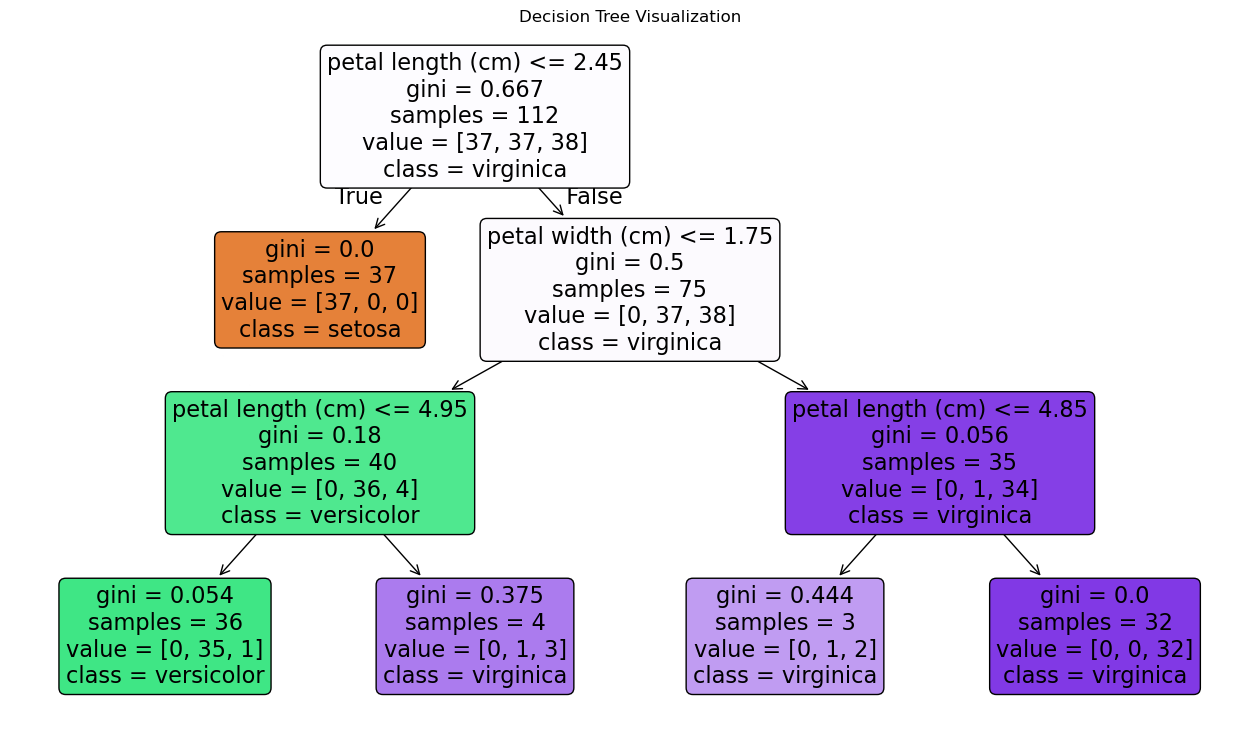

In [138]:
plt.figure(figsize=(16,9))
plot_tree(
    tree_model,
    feature_names=iris_data.feature_names,
    class_names=iris_data.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()

## Step 12: Feature importance


A decision tree can also estimate which input variables were most useful.

In [139]:
importance_df = pd.DataFrame({
    "feature": iris_data.feature_names,
    "importance": tree_model.feature_importances_
}).sort_values(by="importance", ascending = False)

importance_df

,feature,importance
2,petal length (cm),0.594315
3,petal width (cm),0.405685
0,sepal length (cm),0.000000
1,sepal width (cm),0.000000


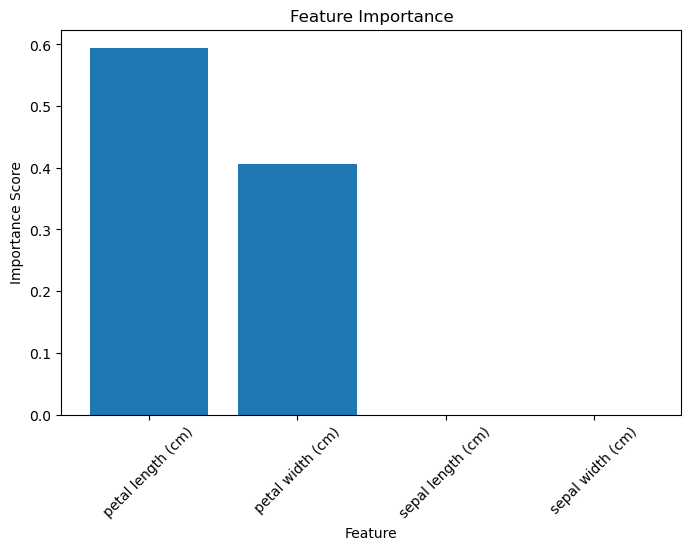

In [140]:
plt.figure(figsize=(8,5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

## Final Conclusion

In this notebook, we completed a full beginner machine learning workflow:

1. loaded the Iris dataset
2. converted the data into a Pandas DataFrame
3. explored and summarized the dataset
4. separated features and target
5. split the data into training and testing sets
6. trained a Decision Tree Classifier
7. predicted flower species
8. evaluated the model
9. visualized both the tree and feature importance

## What this project teaches
This project introduces the basic logic of machine learning:
- data comes first
- features are used to predict a target
- training and testing must be separated
- model performance must be measured
- interpretation matters

This is a solid first project because it teaches the workflow, not just the code.